In [391]:
import xarray as xr
import numpy as np

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*Dataset.dims.*"
)

from tensor_calculus import Tensor

%load_ext autoreload
%autoreload 3

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [407]:
D0 = Tensor(xr.DataArray(np.zeros(2), dims=['i']), label='u_i')
D1 = Tensor(xr.DataArray(np.zeros([2,2]), dims=['i', 'j']), label='@_ju_i')
D2 = Tensor(xr.DataArray(np.zeros([2,2,2]), dims=['i', 'j','k']), label='@_k@_ju_i')
D3 = Tensor(xr.DataArray(np.zeros([2,2,2,2]), dims=['i', 'j','k','m']), label='@_m@_k@_ju_i')
D4 = Tensor(xr.DataArray(np.zeros([2,2,2,2,2]), dims=['i', 'j','k','m','n']), label='@_n@_m@_k@_ju_i')

In [408]:
D2.set_symmetric_indices(['j','k'])
D3.set_symmetric_indices(['j','k', 'm'])
D4.set_symmetric_indices(['j','k', 'm', 'n'])

In [409]:
eps = Tensor.levi_civita()
eps

In [410]:
S1 = 0.5*(D1 + D1.transpose(['i', 'j']))
S1.label = '%_{ij}'
O1 = D1 - S1
O1.label = '&_{ij}'
S1

In [411]:
(D1-S1-O1).hash_array

<xarray.DataArray (i: 2, j: 2)> Size: 32B
array([[0., 0.],
       [0., 0.]])
Dimensions without coordinates: i, j

In [412]:
S2 = 0.5*(D2 + D2.transpose(['i', 'j']))
S2.label = '@_k%_{ij}'
O2 = D2 - S2
O2.label = '@_k&_{ij}'
S2

In [413]:
O2

# Smagorinsky model

In [306]:
((S1*S1).contract(['i','k']).contract(['j','m']).sqrt()*S2).contract(['j', 'k'])

In [307]:
(S1*S1).contract(['i','k']).contract(['j','m']).hash_array

<xarray.DataArray ()> Size: 8B
array(3.56067575)

In [308]:
(S1*D1).contract(['i','m']).contract(['j','k']).hash_array

<xarray.DataArray ()> Size: 8B
array(3.56067575)

In [309]:
(D1-S1-O1).hash_array

<xarray.DataArray (i: 2, j: 2)> Size: 32B
array([[0., 0.],
       [0., 0.]])
Dimensions without coordinates: i, j

In [255]:
from IPython.display import Math, display
for t in (D4).contract_to_rank_one():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [256]:
from IPython.display import Math, display
for t in (D2*D1).contract_to_rank_one():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [239]:
from IPython.display import Math, display
for t in (D3*D0).contract_to_rank_one():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [240]:
from IPython.display import Math, display
for t in (D3*D0*D1).contract_to_rank_one():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Test library construction

In [310]:
from IPython.display import Math, display
from itertools import combinations_with_replacement

def print_basis(results):
    print('Library of tensors has length', len(results))
    for t in results:
        display(Math(f"{t.rename()._repr_latex_()}"))


def construct_basis_of_tensors(initial_tensors, their_derivatives=None, max_nonlinearity = 1, max_derivative=6):
    results = []

    for nonlinearity in range(1, max_nonlinearity+1):
        for idx in combinations_with_replacement(range(0, len(initial_tensors)), nonlinearity):
            tensor = initial_tensors[idx[0]]
            for i in range(1, len(idx)):
                tensor = tensor*initial_tensors[idx[i]]

            sum_derivative = sum([their_derivatives[idx] for idx in idx])
            if sum_derivative > max_derivative:
                continue
            #display(Math(tensor._repr_latex_()+ f'${sum_derivative}$'))

            results.extend(tensor.contract_to_rank_one())

    final_results = []
    unique_hashes = []
    for result in results:
        # Check uniqueness
        hash_array = result.hash_array.values.flatten()
        if not any(np.allclose(hash_array, h) for h in unique_hashes):
            unique_hashes.append(hash_array)
            final_results.append(result)
    
    return final_results

In [311]:
basis = construct_basis_of_tensors([D0, D1, D2, D3, D4], 
                                    [0, 1, 2, 3, 4],
                                    max_nonlinearity=1)
print_basis(basis)

Library of tensors has length 5


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [335]:
# Test that repeating results are filtered out
basis = construct_basis_of_tensors([D1, S1, O1, D2, S2, O2], 
                                    [1, 1, 1, 2, 2, 2],
                                    max_nonlinearity=2, max_derivative=100)
print_basis(basis)

Library of tensors has length 49


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [414]:
basis = construct_basis_of_tensors([eps, D0, D1, D2, S1, S2, O1, O2], 
                                    [0, 0, 1, 2, 1, 2, 1, 2],
                                    max_nonlinearity=3, max_derivative=6)
print_basis(basis)

Library of tensors has length 1149


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [349]:
hash_array = np.array([b.hash_array for b in basis])

In [350]:
hash_array.shape

(975, 2)

In [354]:
corr = np.zeros([975,975])
for i in range(975):
    for j in range(975):
        x, y = hash_array[i], hash_array[j]
        corr[i,j] = (x * y).mean() / (np.sqrt((x**2).mean()) * np.sqrt((y**2).mean()))

/tmp/ipykernel_58597/531086270.py:5: RuntimeWarning: invalid value encountered in scalar divide
  corr[i,j] = (x * y).mean() / (np.sqrt((x**2).mean()) * np.sqrt((y**2).mean()))


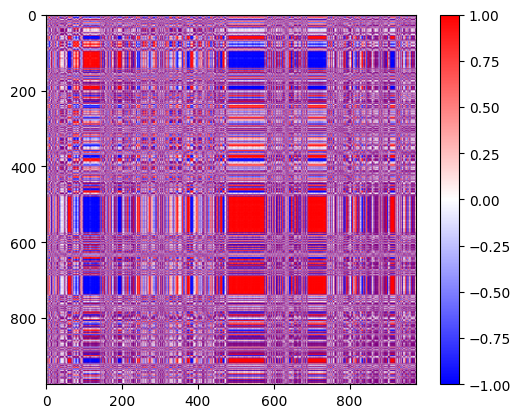

In [361]:
import matplotlib.pyplot as plt
plt.imshow(corr, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()

In [386]:
corr[500,551]

0.999788943011809

In [374]:
basis[500]

In [387]:
basis[551]

In [388]:
def levi_civita(n):
    """Return the Levi-Civita symbol ε_{i1...in} of dimension n."""
    shape = (n,)*n
    eps = np.zeros(shape, dtype=int)
    from itertools import permutations
    for p in permutations(range(n)):
        i = tuple(p)
        # sign of the permutation (even=+1, odd=-1)
        parity = sum(p[i] > p[j] for i in range(n) for j in range(i+1,n))
        eps[i] = -1 if parity % 2 else 1
    return eps

In [390]:
levi_civita(3)

array([[[ 0,  0,  0],
        [ 0,  0,  1],
        [ 0, -1,  0]],

       [[ 0,  0, -1],
        [ 0,  0,  0],
        [ 1,  0,  0]],

       [[ 0,  1,  0],
        [-1,  0,  0],
        [ 0,  0,  0]]])